#  Student Productivity Prediction — XGBoost Regressor

**Dataset:** `ultimate_student_productivity_dataset_5000.csv`  
**Task:** Regression — Prediksi **Productivity Score**  
**Model:** XGBoost Regressor

---
###  Daftar Isi
1–9 semua topik tercakup di bawah

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb
print('Libraries loaded ', 'XGBoost:', xgb.__version__)

Libraries loaded  XGBoost: 3.2.0


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../ultimate_student_productivity_dataset_5000.csv')
print(f'Shape: {df.shape}'); df.info()
print('\nMissing:', df.isnull().sum().sum())
df.describe().round(2)

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,20.52,4.54,2.48,2.01,3.00,1.56,7.02,6.98,74.54,251.45,0.5,0.5,5.51,29.43,45.62,37.27,18.80
std,1443.52,2.87,1.82,1.18,0.98,1.47,1.11,1.16,2.49,42.93,143.84,0.5,0.5,2.87,9.96,14.25,16.85,12.13
min,1.00,16.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,0.00,0.00,0.0,0.0,1.00,1.00,1.00,1.00,1.00
25%,1250.75,18.00,3.25,1.66,1.32,1.99,0.67,6.24,5.28,37.00,129.00,0.0,0.0,3.00,22.57,35.73,25.29,9.34
50%,2500.50,20.00,4.53,2.48,2.01,2.98,1.49,7.01,6.95,75.00,252.00,0.0,1.0,5.00,29.43,45.69,36.86,18.01
75%,3750.25,23.00,5.76,3.29,2.69,4.03,2.34,7.81,8.71,112.00,376.00,1.0,1.0,8.00,36.24,55.35,49.14,27.40
max,5000.00,25.00,11.84,7.41,6.00,8.28,5.64,10.00,15.30,149.00,499.00,1.0,1.0,10.00,63.48,97.58,98.02,64.09


---
## 2.  Dataset Bisa Digunakan Untuk Apa

**XGBoost** pada Student Productivity dataset:
- Mendeteksi **interaksi non-linear** antara fitur (waktu tidur × jam belajar)
- Memberikan **feature importance** untuk intervensi: "apa yang paling mempengaruhi produktivitas?"
- Lebih akurat dari Linear Regression karena data kemungkinan bersifat non-linear

In [3]:
target = 'productivity_score'
drop_cols = ['student_id', 'exam_score']

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target])
y = df_proc[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Target range: {y.min():.1f}–{y.max():.1f}')

Train: (4000, 18), Test: (1000, 18)
Target range: 1.0–98.0


---
## 3.  Mengapa XGBoost?

**XGBoost vs Random Forest vs Linear Regression:**

| Aspek | XGBoost | Random Forest | Ridge |
|-------|---------|---------------|-------|
| Akurasi tabular |  Terbaik | Sangat baik | Cukup |
| Kecepatan training | Sedang | Cepat |  Sangat cepat |
| Regularisasi |  L1+L2 built-in | Terbatas |  L1/L2 |
| Early stopping |  Ya | Tidak | Tidak |
| Feature importance |  Ya |  Ya | Koefisien saja |

**Pilih XGBoost** ketika akurasi adalah prioritas utama.

In [4]:
model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.5, reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror', eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=42, n_jobs=-1, verbosity=0
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f'Training selesai  (best iter: {model.best_iteration})')

Training selesai  (best iter: 173)


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Nilai Default | Pengaruh |
|-----------|-------------|----------|
| `learning_rate` | 0.3 | Lebih kecil → lebih akurat, butuh lebih banyak pohon |
| `max_depth` | 6 | Pohon lebih dalam → kapasitas lebih tinggi, risiko overfit |
| `subsample` | 1.0 | Stochastic boosting untuk mengurangi variance |
| `colsample_bytree` | 1.0 | Feature sampling per pohon |
| `min_child_weight` | 1 | Regularisasi — treshold sum hessian |
| `gamma` | 0 | Min gain untuk split |
| `reg_alpha` | 0 | L1 regularization pada bobot leaf |
| `reg_lambda` | 1 | L2 regularization pada bobot leaf |

---
## 5.  Evaluasi Yang Dipakai

In [5]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print('='*55)
print(' EVALUASI XGBoost REGRESSOR (PRODUCTIVITY)')
print('='*55)
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

 EVALUASI XGBoost REGRESSOR (PRODUCTIVITY)
MAE  : 4.2580
RMSE : 5.2192
R²   : 0.8954
MAPE : 21.47%


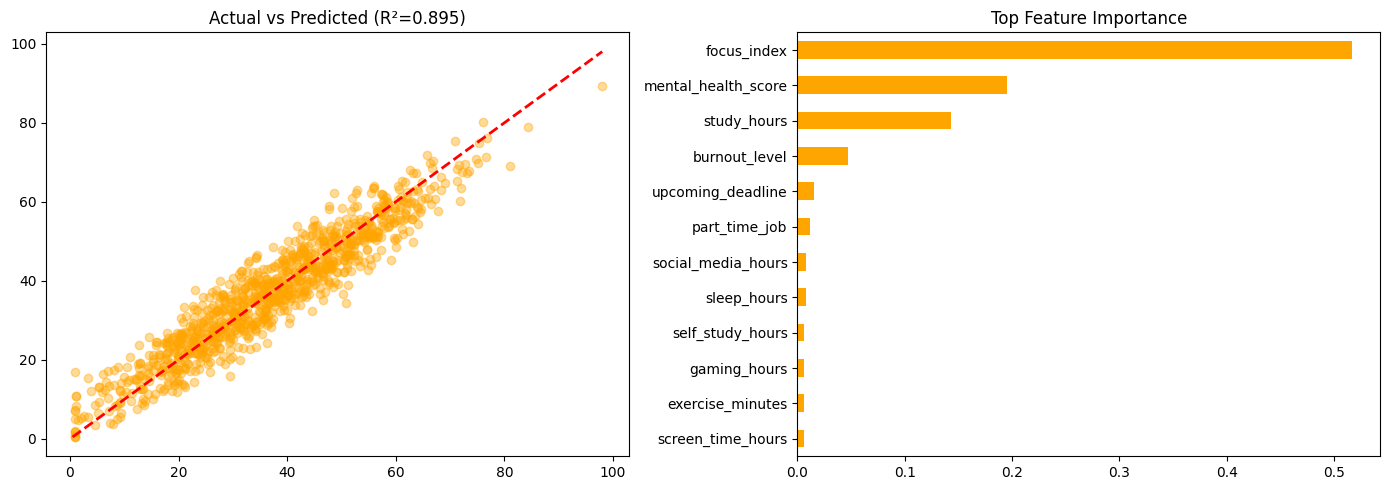

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, alpha=0.4, color='orange')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
feat_imp.plot(kind='barh', ax=axes[1], color='orange')
axes[1].set_title('Top Feature Importance')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

In [7]:
score_range = y.max() - y.min()
r2_train = r2_score(y_train, model.predict(X_train))

print(f'Range skor   : {y.min():.1f} – {y.max():.1f} (range={score_range:.1f})')
print(f'Train R²     : {r2_train:.4f}')
print(f'Test R²      : {r2:.4f}')
print(f'MAE % range  : {mae/score_range*100:.1f}%')
print(f'RMSE % range : {rmse/score_range*100:.1f}%')

gap = r2_train - r2
if gap > 0.1:
    print(f'\n Overfitting (gap={gap:.3f}). Kurangi max_depth, tambah regularisasi')
elif r2 > 0.85:
    print('\n Model sangat baik!')
elif r2 > 0.7:
    print('\n Model baik')
else:
    print('\n Model cukup — lakukan feature engineering lebih lanjut')

Range skor   : 1.0 – 98.0 (range=97.0)
Train R²     : 0.9494
Test R²      : 0.8954
MAE % range  : 4.4%
RMSE % range : 5.4%

 Model sangat baik!


---
## 7.  Cara Mengoptimasi Model

In [8]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.5, 1]
}
rs = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_dist, n_iter=15, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
best = rs.best_estimator_
yp_best = best.predict(X_test)
print(f'Best params: {rs.best_params_}')
print(f'Best R²: {r2_score(y_test, yp_best):.4f}')

Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.9}
Best R²: 0.8907


---
## 8.  Cara Menyimpan Model

In [9]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best, 'saved_models/xgb_reg_productivity.pkl')
best.save_model('saved_models/xgb_reg_productivity.json')
joblib.dump(list(X.columns), 'saved_models/feature_cols_xgb_prod_reg.pkl')
print(' XGBoost Regressor tersimpan!')

 XGBoost Regressor tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [10]:
loaded = joblib.load('saved_models/xgb_reg_productivity.pkl')
cols   = joblib.load('saved_models/feature_cols_xgb_prod_reg.pkl')
print('Model dimuat ')

sample = pd.DataFrame([{
    'age': 20, 'gender': 1, 'academic_level': 1, 'study_hours': 5, 'self_study_hours': 2,
    'online_classes_hours': 2, 'social_media_hours': 2, 'gaming_hours': 1, 'sleep_hours': 7.5,
    'screen_time_hours': 5, 'exercise_minutes': 30, 'caffeine_intake_mg': 150,
    'part_time_job': 0, 'upcoming_deadline': 1, 'internet_quality': 2,
    'mental_health_score': 7, 'focus_index': 7, 'burnout_level': 3
}])[cols]

pred = loaded.predict(sample)[0]
print(f'\nPrediksi Productivity Score: {pred:.1f}')
print(f'Interpretasi: {"Sangat Produktif " if pred >= 75 else ("Produktif " if pred >= 50 else "Perlu Peningkatan ")}')

Model dimuat 

Prediksi Productivity Score: 44.0
Interpretasi: Perlu Peningkatan 
